# **Tutorial 1: Neural Networks in PyTorch**

This notebook re-implements exercises from Tutorials 10 and 11 of the machine learning course using PyTorch.

PyTorch has been adopted as the primary deep learning framework because it underpins many modern generative models, including large language models (LLMs), transformers, and diffusion models. Developing proficiency in PyTorch will provide the practical foundation required for the advanced topics covered later in the course.


## Learning Outcomes
By the end of this lab you will be able to:
- Install and verify PyTorch
- Create and manipulate tensors (equivalent to TF tensors)
- Use Autograd for automatic differentiation
- Build models with `nn.Module` (equivalent to `tf.keras.Sequential`)
- Use loss functions and optimisers
- Write a training loop manually (instead of `model.fit()`)
- Train, evaluate and visualise the same models you built in TF — on the same datasets
- Apply Early Stopping and Dropout in PyTorch
- Save and reload trained models

---
## Part 1: Installing PyTorch

In VS Code Terminal:
```bash
pip install torch torchvision torchaudio matplotlib scikit-learn pandas
```
Then restart the kernel and run the cell below.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, r2_score

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

# Detect best available device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device    :", device)

PyTorch version : 2.13.0
CUDA available  : False
Using device    : mps


---
## Part 2: Tensors

In Tutorial 10, TensorFlow described tensors as multi-dimensional arrays — scalars, vectors, matrices, and higher-dimensional structures. PyTorch tensors are exactly the same concept.

### Tensor ranks

| Rank | Name | Example shape | Example meaning |
|------|------|---------------|-----------------|
| 0 | Scalar | `()` | A single loss value |
| 1 | Vector | `(4,)` | One land sample: Rainfall, Soil_pH, Slope, Elevation |
| 2 | Matrix | `(32, 4)` | A mini-batch of 32 land samples |
| 3 | 3-D tensor | `(32, 28, 28)` | 32 greyscale images |

### PyTorch vs TensorFlow tensors

- TF tensors are immutable by default; PyTorch tensors are mutable like NumPy arrays.
- In TF you used `tf.Variable` for trainable parameters. In PyTorch every `nn.Parameter` is a tensor with `requires_grad=True`.
- Both support GPU acceleration — PyTorch uses `.to(device)`; TF uses `tf.device`.

### Data types (dtype)

| dtype | Use |
|-------|-----|
| `torch.float32` | Network weights, features (default for floats) |
| `torch.int64` | Class labels — required by `CrossEntropyLoss` |
| `torch.bool` | Masks |

In Tutorial 10, `StandardScaler` returned `float64` NumPy arrays. When converting to PyTorch tensors always cast to `float32` using `torch.FloatTensor()` or `.float()`.

In [2]:
import torch

# --- Creating tensors from the land_suitability dataset ---
# One land sample: Rainfall=1200, Soil_pH=6.8, Slope=5, Elevation=200
sample = torch.tensor([1200.0, 6.8, 5.0, 200.0])   # Rainfall, Soil_pH, Slope, Elevation
print("Sample tensor :", sample)
print("Shape         :", sample.shape)   # torch.Size([4])
print("dtype         :", sample.dtype)   # torch.float32

# A matrix: two land samples
batch = torch.tensor([
    [1200.0, 6.8,  5.0, 200.0],   # Suitable
    [ 900.0, 5.5, 12.0, 350.0]    # Not Suitable
])
print("\nBatch shape   :", batch.shape)  # torch.Size([2, 4])

Sample tensor : tensor([1200.0000,    6.8000,    5.0000,  200.0000])
Shape         : torch.Size([4])
dtype         : torch.float32

Batch shape   : torch.Size([2, 4])


In [3]:
# Factory functions- same patterns as TF
zeros  = torch.zeros((3, 4))          # tf.zeros()
ones   = torch.ones((3, 4))           # tf.ones()
random = torch.randn((3, 4))          # tf.random.normal()
eye    = torch.eye(4)                 # identity matrix
arange = torch.arange(0, 10, 2)      # like Python range()

print("Zeros:\n", zeros)
print("Random Normal:\n", random)
print("Arange:", arange)

Zeros:
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
Random Normal:
 tensor([[-0.7746,  0.6203,  0.8403,  1.5338],
        [-2.5030, -0.3411,  0.5984,  0.0955],
        [ 1.5276,  1.0592,  1.2952, -0.6990]])
Arange: tensor([0, 2, 4, 6, 8])


In [4]:
# dtype: always check when converting from NumPy (StandardScaler returns float64)
import numpy as np

np_array = np.array([1200.0, 6.8, 5.0, 200.0])   # float64 from StandardScaler
print("NumPy dtype :", np_array.dtype)             # float64

# Correct conversion for neural network input
tensor_f32 = torch.FloatTensor(np_array)           # float32 - what the network expects
print("Tensor dtype:", tensor_f32.dtype)           # torch.float32

# Labels must be int64 for CrossEntropyLoss, float32 for BCELoss
labels_long  = torch.tensor([0, 1, 1, 0], dtype=torch.int64)   # multiclass
labels_float = torch.tensor([0., 1., 1., 0.], dtype=torch.float32)  # binary (land suitability)
print("Label dtype (int64) :", labels_long.dtype)
print("Label dtype (float) :", labels_float.dtype)

NumPy dtype : float64
Tensor dtype: torch.float32
Label dtype (int64) : torch.int64
Label dtype (float) : torch.float32


###  Exercise 1 — Creating tensors

1. Create a tensor representing one weather sample: `AirTemp_C=22.5`, `Rain_mm=4.1`, `WindSpeed_mps=3.8`. Print its shape and dtype.
2. Create a (5, 3) tensor of zeros to represent 5 blank weather samples (3 features each).
3. Convert `np.array([22.5, 4.1, 3.8])` to a `float32` PyTorch tensor.
4. Explain in one sentence why we use `torch.FloatTensor` and not the default NumPy dtype.

In [10]:
# ---- Exercise 1 Solutions ----
import torch, numpy as np

# 1. One weather sample with 3 features (same features used in Tutorial 10/11)
weather_sample = torch.tensor([22.5, 4.1, 3.8])
print("1. shape:", weather_sample.shape, "dtype:", weather_sample.dtype)

# 2. Blank batch of 5 weather samples
blank = torch.zeros((5, 3))
print("2.\n", blank)

# 3. Convert NumPy array to float32 tensor
np_w = np.array([22.5, 4.1, 3.8])
tensor_w = torch.FloatTensor(np_w)
print("3.", tensor_w, "dtype:", tensor_w.dtype)

# 4. Answer:
# StandardScaler and most NumPy operations return float64, but PyTorch nn.Linear
# layers use float32 by default, mismatched dtypes cause a RuntimeError.

1. shape: torch.Size([3]) dtype: torch.float32
2.
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
3. tensor([22.5000,  4.1000,  3.8000]) dtype: torch.float32


---
## Part 3: Tensor Operations

These are the same arithmetic operations you used implicitly inside TF/Keras layers. Understanding them at tensor level makes debugging much easier.

The equation for a single neuron, introduced in Tutorial 10:

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

In [11]:
import torch

# Replicating what a Dense(1) layer does manually with land_suitability features:
# y = w * x + b  (the equation from Tutorial 10)

# One land sample: Rainfall=1200, Soil_pH=6.8, Slope=5, Elevation=200
x = torch.tensor([1200.0, 6.8, 5.0, 200.0])

# Weights (one per input feature) and bias - normally learned by training
w = torch.tensor([0.01, 0.5, -0.3, 0.002])
b = torch.tensor(0.1)

# Forward computation - this is exactly what nn.Linear does under the hood
z = torch.dot(w, x) + b
print("Dot product w·x + b =", z.item())
print("\nNote: torch.dot() = element-wise multiply then sum")
print("w * x  =", w * x)
print("sum    =", (w * x).sum().item())

Dot product w·x + b = 14.40000057220459

Note: torch.dot() = element-wise multiply then sum
w * x  = tensor([12.0000,  3.4000, -1.5000,  0.4000])
sum    = 14.299999237060547


In [12]:
# Common operations on a batch (matrix) of land samples
# shape: (10 samples, 4 features: Rainfall, Soil_pH, Slope, Elevation)
X = torch.randn(10, 4)

print("Mean per feature :", X.mean(dim=0))   # average across 10 samples for each feature
print("Std per feature  :", X.std(dim=0))
print("Max value        :", X.max().item())
print("Shape            :", X.shape)

# Reshape - very common when preparing batches
x_flat = torch.arange(12).float()
print("\nFlat:", x_flat.shape)
print("Reshaped (3,4):\n", x_flat.reshape(3, 4))

Mean per feature : tensor([-0.3127,  0.1869,  0.1216, -0.2303])
Std per feature  : tensor([1.2263, 0.7741, 1.0423, 1.1481])
Max value        : 2.059731960296631
Shape            : torch.Size([10, 4])

Flat: torch.Size([12])
Reshaped (3,4):
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])


In [13]:
# Matrix multiplication  what happens inside nn.Linear for a whole batch
# X shape: (batch, features), W shape: (features, out)
# Output: X @ W  shape: (batch, out)

X = torch.randn(5, 4)     # 5 land samples, 4 features
W = torch.randn(4, 1)     # weight matrix - 4 inputs, 1 output neuron
b = torch.zeros(1)        # bias

out = X @ W + b           # equivalent to one Dense(1) layer (no activation)
print("Output shape:", out.shape)   # (5, 1)
print(out)

Output shape: torch.Size([5, 1])
tensor([[-2.6478],
        [ 0.2129],
        [ 0.7516],
        [-0.0520],
        [ 2.5345]])


###  Exercise 2 — Operations

1. Create a (3, 5) weight matrix and a (5,) bias vector with random values. Multiply a batch of 8 weather samples `(8, 3)` through them to get an output of shape `(8, 5)`. This is what one `Dense(5)` layer does.
2. Given predictions `p = torch.tensor([0.8, 0.2, 0.9, 0.4])` and targets `t = torch.tensor([1., 0., 1., 0.])` (land suitability labels), manually compute MSE: `((p - t)**2).mean()`. Verify it matches `nn.MSELoss()(p, t)`.

In [9]:
# ---- Exercise 2 Solutions ----
import torch
import torch.nn as nn

# 1. Dense(5) equivalent for weather inputs (3 features -> 5 neurons)
X_w = torch.randn(8, 3)    # 8 weather samples: AirTemp_C, Rain_mm, WindSpeed_mps
W   = torch.randn(3, 5)    # weight matrix - 3 inputs, 5 outputs
b   = torch.zeros(5)       # bias
out = X_w @ W + b
print("1. Output shape:", out.shape)   # (8, 5)

# 2. MSE for land suitability predictions
p = torch.tensor([0.8, 0.2, 0.9, 0.4])
t = torch.tensor([1., 0., 1., 0.])   # Suitable/Not Suitable labels

mse_manual = ((p - t)**2).mean()
mse_keras  = nn.MSELoss()(p, t)
print("2. Manual MSE  :", mse_manual.item())
print("   nn.MSELoss  :", mse_keras.item())
print("   Match       :", torch.isclose(mse_manual, mse_keras).item())

1. Output shape: torch.Size([8, 5])
2. Manual MSE  : 0.0625
   nn.MSELoss  : 0.0625
   Match       : True


---
## Part 4: Working with Devices (CPU / GPU)

### What is a device in PyTorch?

A **device** is where PyTorch stores tensors and performs computations.  
PyTorch supports three devices:

| Device | When available | Speed |
|--------|----------------|-------|
| `cpu` | Always | Baseline |
| `cuda` | NVIDIA GPU present + CUDA drivers installed | 10–100× faster for large models |
| `mps` | Apple Silicon Mac (M1/M2/M3) + macOS 12.3+ | Faster than CPU on Mac |

The device detection block in **Part 1** already picked the best available device for your machine and stored it in the variable `device`.

### Why does it matter?

Every tensor and every model lives on exactly **one device** at a time.  
If your model is on `cuda` but your input tensor is on `cpu`, PyTorch raises:

```
RuntimeError: Expected all tensors to be on the same device
```

The golden rule:  
> **model → device** once (at model creation), **data → device** every batch (inside the training loop).

### The `.to(device)` method

`.to(device)` returns a copy of the tensor/model on the target device *(non-destructive for tensors)*.  
For models, `.to(device)` is **in-place**.

```python
model.to(device)          # in-place — model itself is moved
x = x.to(device)         # returns a new tensor on device
```

### Checking what device a tensor is on

```python
print(x.device)           # e.g. device(type='cuda', index=0)  or  cpu
```

### Moving back to CPU for NumPy / sklearn

NumPy and sklearn only work with CPU tensors.  
Before calling `.numpy()` or passing to `accuracy_score`, always:

```python
y_pred = model(X_test).cpu().detach().numpy()
```

`detach()` removes the tensor from the computation graph (no grad tracking needed for inference).

---
**Tip for this lab:**  
Most machines will show `device: cpu`. That is perfectly fine — all models in this tutorial are small and will train in seconds on CPU. The device-aware code is written so it will automatically use GPU/MPS if available, without any changes.


In [10]:
#  Part 4: Device demo
# 'device' was detected and set in Part 1 (cpu / cuda / mps)
print("Active device :", device)
print()

# --- Tensor to device ---
x = torch.tensor([1200.0, 6.8, 5.0, 200.0]).to(device)
print("Tensor location :", x.device)   # e.g. cpu  or  cuda:0

# --- Model - device (call .to(device) right after model creation) ---
demo_model = nn.Sequential(nn.Linear(4, 1))
demo_model.to(device)
print("Model parameter device:", next(demo_model.parameters()).device)

# --- Forward pass: both must be on the same device ---
out = demo_model(x)
print("Forward pass output :", out.item())

# --- Return to CPU for NumPy/sklearn ---
x_cpu = x.cpu()
print("Back on CPU :", x_cpu.device)

# --- .cpu().detach().numpy() idiom (used in every evaluation cell) ---
arr = out.cpu().detach().numpy()
print("As NumPy array :", arr)

# --- GPU info (shown only when CUDA is available) ---
if torch.cuda.is_available():
    print()
    print("=== CUDA / GPU Info ===")
    print("GPU count  :", torch.cuda.device_count())
    print("GPU name   :", torch.cuda.get_device_name(0))
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU memory : {mem:.1f} GB")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print()
    print("=== Apple MPS (Metal) GPU ===")
    print("MPS device is available and active.")
else:
    print()
    print("Running on CPU - all models in this tutorial train in seconds on CPU.")
    print("No GPU required.")


Active device : mps

Tensor location : mps:0
Model parameter device: mps:0
Forward pass output : 276.5634460449219
Back on CPU : cpu
As NumPy array : [276.56345]

=== Apple MPS (Metal) GPU ===
MPS device is available and active.


###  Where does PyTorch run your code? (CPU vs GPU)

When you run the detection block in Part 1, PyTorch checks your machine and sets a variable called `device`. Think of `device` as PyTorch's answer to the question: *"Where should I do the heavy maths?"*

You will see one of these printed:

| What you see | What it means |
|---|---|
| `Using device: cpu` | Your laptop/desktop CPU — perfectly fine for this tutorial |
| `Using device: cuda` | An NVIDIA GPU is available (e.g. university server, Colab GPU) |
| `Using device: mps` | Apple Silicon Mac (M1/M2/M3) GPU |





### The one rule you must follow

> **Your model and your data must always be on the same device.**

If your model is on the GPU but your data is on the CPU (or vice versa), PyTorch will crash with:

RuntimeError: Expected all tensors to be on the same device



### How to follow that rule

**Step 1 — Move your model right after you create it:**
```python
model = ShallowClassifier()
model.to(device)   # ← always do this immediately after creating a model
```

**Step 2 — Move your data tensors after you create them (Part 9):**
```python
X_tr_c_t = X_tr_c_t.to(device)
y_tr_c_t = y_tr_c_t.to(device)
# repeat for all tensors
```

**Step 3 — Move predictions back to CPU before using sklearn:**  
sklearn and NumPy only understand CPU data. So before calling `accuracy_score`, `r2_score`, or `.numpy()`, always do:
```python
y_pred = model(X_test).cpu().detach().numpy()
#                       ^^^   ^^^^^^^^
#                       |     removes gradient tracking (not needed at inference)
#                       moves tensor back to CPU
```


### Do I need to worry about this right now?

**No — if you are on your own laptop**, `device` will be `cpu`, your model and data are already in the same place, and everything just works.

**Yes — if you move to a GPU machine** (university server, Google Colab with GPU runtime), add the `.to(device)` calls above or your code will crash.

The training functions in Parts 13–14 of this tutorial deliberately keep everything on CPU so the code is easy to read and follow. That is fine here because the datasets are small and training takes only seconds. On larger real-world datasets you would always use a GPU and move data in mini-batches inside the training loop — but that is covered in a later tutorial.

---
## Part 5: Automatic Differentiation (Autograd)

In Tutorial 10 you implemented a perceptron from scratch using the weight update rule:

$$w_{i+1} = w_i + \eta \cdot (y - \hat{y}) \cdot x_i$$

And you computed gradients manually:
```python
dw = -2 * x * (y - y_hat)
db = -2 * (y - y_hat)
w -= lr * dw
b -= lr * db
```

PyTorch's **Autograd** does this automatically for any computation graph. When a tensor has `requires_grad=True`, PyTorch records every operation on it. Calling `.backward()` traverses that record in reverse and deposits gradients in each tensor's `.grad` attribute.

> In TensorFlow 2 you used `with tf.GradientTape()` to record operations explicitly. In PyTorch the recording is implicit — it happens automatically for any tensor with `requires_grad=True`.

In [11]:
import torch

# Recreate the from-scratch regression from Tutorial 10 using Autograd
# y = 0.75 * x   the weight should converge to 0.75
# (same simple dataset used in Tutorial 10 to demonstrate the perceptron)

X_data = torch.tensor([0., 1., 2., 3., 4.])
Y_data = torch.tensor([0., 0.75, 1.5, 2.25, 3.])

# Learnable parameters  requires_grad=True tells PyTorch to track them
w = torch.tensor([0.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

lr = 0.05

for epoch in range(100):
    # Forward pass
    y_hat = w * X_data + b

    # MSE loss
    loss = ((Y_data - y_hat) ** 2).mean()

    # Backward pass - Autograd computes dLoss/dw and dLoss/db
    loss.backward()

    # Manually update (no optimizer yet) - same formula as Tutorial 10
    with torch.no_grad():   # don't track the update step itself
        w -= lr * w.grad
        b -= lr * b.grad

    # Zero gradients - MUST do before next backward() call
    w.grad.zero_()
    b.grad.zero_()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.6f} | w: {w.item():.4f} | b: {b.item():.4f}")

print(f"\nFinal weight: {w.item():.4f}  (expected 0.75)")
print(f"Final bias  : {b.item():.4f}  (expected 0.00)")
print("\nThis is exactly what model.fit() was doing internally in Tutorial 10.")

Epoch   0 | Loss: 3.375000 | w: 0.4500 | b: 0.1500
Epoch  20 | Loss: 0.005474 | w: 0.7065 | b: 0.1240
Epoch  40 | Loss: 0.001629 | w: 0.7263 | b: 0.0676
Epoch  60 | Loss: 0.000485 | w: 0.7371 | b: 0.0369
Epoch  80 | Loss: 0.000144 | w: 0.7429 | b: 0.0201

Final weight: 0.7460  (expected 0.75)
Final bias  : 0.0113  (expected 0.00)

This is exactly what model.fit() was doing internally in Tutorial 10.


###  Exercise 3 — Autograd

1. Verify that for `w = 5.0` in `loss = (0.75*x - w*x)**2` the gradient with respect to `w` is non-zero. Print the gradient.
2. Demonstrate gradient accumulation: call `loss.backward()` twice without zeroing, and show that `.grad` doubles. Then zero and confirm it resets.
3. In one sentence: why must `optimizer.zero_grad()` be called before `loss.backward()` in every training step?

In [12]:
# ---- Exercise 3 Solutions ----
import torch

# 1.
x = torch.tensor([1., 2., 3., 4.])
w = torch.tensor([5.0], requires_grad=True)
loss = ((0.75*x - w*x)**2).mean()
loss.backward()
print("1. Gradient at w=5:", w.grad.item())

# 2. Gradient accumulation demonstration
w2 = torch.tensor([0.5], requires_grad=True)
for step in range(2):
    l = (w2 * torch.tensor([1., 2., 3.])).sum()
    l.backward()
    print(f"   After backward #{step+1}: grad = {w2.grad.item()}")

w2.grad.zero_()
l = (w2 * torch.tensor([1., 2., 3.])).sum()
l.backward()
print("   After zero_ + backward:", w2.grad.item())

# 3. Answer:
# PyTorch accumulates gradients across .backward() calls. Without zeroing first,
# each iteration adds to the previous iteration's gradients, corrupting the weight update.

1. Gradient at w=5: 63.75
   After backward #1: grad = 6.0
   After backward #2: grad = 12.0
   After zero_ + backward: 6.0


---
## Part 6: Building Models with `nn.Module`

`nn.Module` is PyTorch's equivalent of `tf.keras.Sequential`. You define the layers in `__init__` and describe the forward pass in `forward(x)`.

### The two required methods

| Method | Purpose | Keras equivalent |
|--------|---------|------------------|
| `__init__` | Define and register layers | `Sequential([Dense(...), ...])` |
| `forward(x)` | Describe the data flow | Handled automatically by Keras |

PyTorch derives `backward()` automatically from your `forward()` via Autograd.

### Common activation functions — PyTorch vs Keras (from Tutorial 10)

| Keras | PyTorch | Formula | Use |
|-------|---------|---------|-----|
| `activation='relu'` | `nn.ReLU()` | max(0, x) | Hidden layers |
| `activation='sigmoid'` | `nn.Sigmoid()` | 1/(1+e⁻ˣ) | Binary output |
| `activation='softmax'` | `nn.Softmax(dim=1)` | eˣᵢ / Σeˣⱼ | Multiclass output |
| `activation='tanh'` | `nn.Tanh()` | (eˣ−e⁻ˣ)/(eˣ+e⁻ˣ) | Hidden layers, RNNs |
| `activation='linear'` | *(no layer needed)* | f(x) = x | Regression output |

In [13]:
import torch.nn as nn

#  Keras equivalent: tf.keras.Sequential([Dense(8,'relu'), Dense(1,'sigmoid')]) 
# Predicts land suitability (4 inputs: Rainfall, Soil_pH, Slope, Elevation)

quick_model = nn.Sequential(
    nn.Linear(4, 8),    # Dense(8, activation='relu', input_shape=(4,))
    nn.ReLU(),
    nn.Linear(8, 1),    # Dense(1, activation='sigmoid')
    nn.Sigmoid()
)

print(quick_model)
print("\nParameters:")
for name, p in quick_model.named_parameters():
    print(f"  {name:20s}  shape={p.shape}  count={p.numel()}")
print("Total:", sum(p.numel() for p in quick_model.parameters()))

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
  (3): Sigmoid()
)

Parameters:
  0.weight              shape=torch.Size([8, 4])  count=32
  0.bias                shape=torch.Size([8])  count=8
  2.weight              shape=torch.Size([1, 8])  count=8
  2.bias                shape=torch.Size([1])  count=1
Total: 49


In [14]:
# How nn.Linear works - the equation from Tutorial 10
# y = W * x + b  where W has shape (out_features, in_features)

layer = nn.Linear(4, 1)   # 4 land inputs, 1 output

print("Weight shape :", layer.weight.shape)   # (1, 4)
print("Bias shape   :", layer.bias.shape)     # (1,)
print("Parameters   :", layer.weight.numel() + layer.bias.numel())

# Pass one real land sample through
sample = torch.tensor([[1200.0, 6.8, 5.0, 200.0]])   # shape (1, 4)
out = layer(sample)
print("Output       :", out.item())

Weight shape : torch.Size([1, 4])
Bias shape   : torch.Size([1])
Parameters   : 5
Output       : 202.40211486816406


---
## Part 7: Loss Functions

The same loss functions from Tutorial 10 exist in PyTorch:

| Task | Keras | PyTorch | Notes |
|------|-------|---------|-------|
| Regression | `loss='mse'` | `nn.MSELoss()` | |
| Regression | `loss='mae'` | `nn.L1Loss()` | |
| Binary classification | `loss='binary_crossentropy'` | `nn.BCELoss()` | Needs Sigmoid output |
| Binary (stable) | — | `nn.BCEWithLogitsLoss()` | No Sigmoid needed — preferred |
| Multiclass | `loss='sparse_categorical_crossentropy'` | `nn.CrossEntropyLoss()` | No Softmax needed |

In [15]:
import torch
import torch.nn as nn

# MSE - same as loss='mse' in Keras regression (Tutorial 10: predicting Humidity_pct)
mse = nn.MSELoss()
pred_reg = torch.tensor([[62.0], [58.5], [71.0]])  # predicted humidity
true_reg = torch.tensor([[65.0], [57.0], [70.5]])  # actual humidity
print("MSE Loss (humidity prediction):", mse(pred_reg, true_reg).item())

# BCE - same as loss='binary_crossentropy' in Keras (Tutorial 10/11: land suitability)
bce = nn.BCELoss()
# Predicted probabilities of 'Suitable' class
pred_cls = torch.tensor([[0.85], [0.20], [0.90], [0.35]])
true_cls  = torch.tensor([[1.0],  [0.0],  [1.0],  [0.0]])   # Suitable / Not Suitable
print("BCE Loss (land suitability)   :", bce(pred_cls, true_cls).item())

# Verify: higher loss when predictions are wrong
bad_pred = torch.tensor([[0.1], [0.9], [0.1], [0.9]])
print("BCE Loss (wrong predictions)  :", bce(bad_pred, true_cls).item())

MSE Loss (humidity prediction): 3.8333332538604736
BCE Loss (land suitability)   : 0.23045146465301514
BCE Loss (wrong predictions)  : 2.3025851249694824


---
## Part 8: Optimisers

PyTorch includes the same optimisers as Keras:

| Keras | PyTorch |
|-------|---------| 
| `Adam(learning_rate=0.001)` | `optim.Adam(model.parameters(), lr=0.001)` |
| `SGD(learning_rate=0.01)` | `optim.SGD(model.parameters(), lr=0.01)` |
| `Adam` with weight decay | `optim.AdamW(...)` |

The key difference: in Keras the optimiser is passed to `model.compile()`. In PyTorch you create it separately and call `optimizer.step()` yourself inside the training loop.

Common learning rates (same as Tutorial 10):

| Learning Rate | Effect |
|---|---|
| 0.01 | High, may be unstable |
| 0.001 | Default, good starting point |
| 0.0001 | Low, slow but stable |

In [16]:
import torch.optim as optim

# Same optimiser choices as Tutorial 10 and 11
model_temp = nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())

adam_opt  = optim.Adam(model_temp.parameters(), lr=0.001)
sgd_opt   = optim.SGD(model_temp.parameters(),  lr=0.01, momentum=0.9)
adamw_opt = optim.AdamW(model_temp.parameters(), lr=0.001, weight_decay=1e-4)

print("Adam  :", type(adam_opt).__name__)
print("SGD   :", type(sgd_opt).__name__)
print("AdamW :", type(adamw_opt).__name__)

Adam  : Adam
SGD   : SGD
AdamW : AdamW


---
## Part 9: Preparing the Datasets

We now load the **same two datasets** from Tutorials 10 and 11:
- **`land_suitability.csv`** — binary classification (Suitable / Not Suitable)
- **`Weather_Data.csv`** — regression (predict Humidity_pct)

The preprocessing steps are **identical** to what you did in the TF labs.

| Feature | Dataset | Role |
|---------|---------|------|
| Rainfall, Soil_pH, Slope, Elevation | land_suitability.csv | Inputs (X) |
| Suitability | land_suitability.csv | Target — 0 or 1 |
| AirTemp_C, Rain_mm, WindSpeed_mps | Weather_Data.csv | Inputs (X) |
| Humidity_pct | Weather_Data.csv | Target — continuous |

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ------- CLASSIFICATION DATASET: land_suitability.csv -------
# Same dataset used in Tutorial 10 (Perceptron for Classification) and Tutorial 11
df_land = pd.read_csv("data/land_suitability.csv")
print("Land suitability dataset:")
print(df_land.head())
print(df_land.shape)
print("\nFeatures:", list(df_land.drop(columns=['Suitability']).columns))
print("Target  : Suitability (0 = Not Suitable, 1 = Suitable)")

Land suitability dataset:
   Rainfall  Soil_pH  Slope  Elevation  Suitability
0      1200      6.8      5        200            1
1       900      5.5     12        350            0
2      1500      7.0      3        180            1
3       800      5.2     15        420            0
4      1300      6.5      6        220            1
(50, 5)

Features: ['Rainfall', 'Soil_pH', 'Slope', 'Elevation']
Target  : Suitability (0 = Not Suitable, 1 = Suitable)


In [18]:
# Same split as Tutorial 10 and 11: 60% train, 20% val, 20% test
y_land = df_land["Suitability"].values
X_land = df_land.drop(columns=["Suitability"]).values

X_tr_c, X_tmp_c, y_tr_c, y_tmp_c = train_test_split(X_land, y_land, test_size=0.40, random_state=42)
X_val_c, X_te_c, y_val_c, y_te_c = train_test_split(X_tmp_c, y_tmp_c, test_size=0.50, random_state=42)

# Feature scaling - same as Tutorial 10/11 (fit on train only to prevent data leakage)
scaler_c = StandardScaler()
X_tr_c  = scaler_c.fit_transform(X_tr_c)
X_val_c = scaler_c.transform(X_val_c)
X_te_c  = scaler_c.transform(X_te_c)

print(f"Classification - Train: {X_tr_c.shape}  Val: {X_val_c.shape}  Test: {X_te_c.shape}")

# Convert to PyTorch tensors
# Features: float32   |   Labels: float32 for BCELoss (same as Keras binary_crossentropy)
X_tr_c_t  = torch.FloatTensor(X_tr_c)
X_val_c_t = torch.FloatTensor(X_val_c)
X_te_c_t  = torch.FloatTensor(X_te_c)

y_tr_c_t  = torch.FloatTensor(y_tr_c).reshape(-1, 1)
y_val_c_t = torch.FloatTensor(y_val_c).reshape(-1, 1)
y_te_c_t  = torch.FloatTensor(y_te_c).reshape(-1, 1)

Classification - Train: (30, 4)  Val: (10, 4)  Test: (10, 4)


In [19]:
# ------- REGRESSION DATASET: Weather_Data.csv -------
# Same dataset used in Tutorial 10 (Perceptron for Regression) and Tutorial 11
df_weather = pd.read_csv("data/Weather_Data.csv")
df_weather = df_weather.dropna()
print("Weather dataset:")
print(df_weather.head())
print(df_weather.shape)
print("\nInputs :", ['AirTemp_C', 'Rain_mm', 'WindSpeed_mps'])
print("Target  : Humidity_pct")

Weather dataset:
   AirTemp_C  Rain_mm  WindSpeed_mps  Humidity_pct
0       22.5      0.0            3.2            68
1       22.1      0.0            3.1            69
2       21.8      0.0            2.9            70
3       21.4      0.0            2.8            71
4       21.0      0.0            2.6            72
(48, 4)

Inputs : ['AirTemp_C', 'Rain_mm', 'WindSpeed_mps']
Target  : Humidity_pct


In [20]:
# Same features and split as Tutorial 10 and 11
X_weather = df_weather[['AirTemp_C', 'Rain_mm', 'WindSpeed_mps']].values
y_weather = df_weather['Humidity_pct'].values.reshape(-1, 1)

X_tr_r, X_tmp_r, y_tr_r, y_tmp_r = train_test_split(X_weather, y_weather, test_size=0.40, random_state=42)
X_val_r, X_te_r, y_val_r, y_te_r = train_test_split(X_tmp_r, y_tmp_r, test_size=0.50, random_state=42)

# Scale features (same as Tutorial 10/11)
x_scaler_r = StandardScaler()
X_tr_r  = x_scaler_r.fit_transform(X_tr_r)
X_val_r = x_scaler_r.transform(X_val_r)
X_te_r  = x_scaler_r.transform(X_te_r)

# Scale target (same as Tutorial 10 - neural networks struggle with large output values)
y_scaler_r = StandardScaler()
y_tr_r  = y_scaler_r.fit_transform(y_tr_r)
y_val_r = y_scaler_r.transform(y_val_r)
y_te_r  = y_scaler_r.transform(y_te_r)

print(f"Regression - Train: {X_tr_r.shape}  Val: {X_val_r.shape}  Test: {X_te_r.shape}")

# Convert to tensors
X_tr_r_t  = torch.FloatTensor(X_tr_r)
X_val_r_t = torch.FloatTensor(X_val_r)
X_te_r_t  = torch.FloatTensor(X_te_r)

y_tr_r_t  = torch.FloatTensor(y_tr_r)
y_val_r_t = torch.FloatTensor(y_val_r)
y_te_r_t  = torch.FloatTensor(y_te_r)

Regression - Train: (28, 3)  Val: (10, 3)  Test: (10, 3)


---
## Part 10: Perceptron for Regression — Weather Dataset (Tutorial 10 Equivalent)

In Tutorial 10 you built a single-neuron model in Keras:
```python
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, activation='linear', input_shape=(3,))
])
model.compile(loss='mse', optimizer=Adam(lr=0.001), metrics=['mae'])
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val))
```

Here is the **exact same model** in PyTorch. Inputs: `AirTemp_C`, `Rain_mm`, `WindSpeed_mps` → Target: `Humidity_pct`.

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

# Single linear neuron - equivalent to Dense(1, activation='linear')
# Inputs: AirTemp_C, Rain_mm, WindSpeed_mps (3 features)
# Output: Humidity_pct (1 value - regression)
perceptron_reg = nn.Sequential(
    nn.Linear(3, 1)   # No activation = linear - same as activation='linear' in Keras
)

criterion = nn.MSELoss()                                       # same as loss='mse'
optimizer = optim.Adam(perceptron_reg.parameters(), lr=0.001)  # same as Adam(lr=0.001)

print(perceptron_reg)
print("Parameters:", sum(p.numel() for p in perceptron_reg.parameters()))

Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
)
Parameters: 4


In [22]:
# The training loop - what model.fit() does internally
# In Tutorial 10, Keras did all of this for you automatically.
# In PyTorch you write it explicitly - but the 5 steps are always the same.

NUM_EPOCHS = 200
loss_hist_r = []
val_loss_hist_r = []

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    perceptron_reg.train()

    outputs = perceptron_reg(X_tr_r_t)       # 1. Forward pass
    loss    = criterion(outputs, y_tr_r_t)   # 2. Compute loss
    optimizer.zero_grad()                    # 3. Zero gradients
    loss.backward()                          # 4. Backpropagation
    optimizer.step()                         # 5. Update weights
    loss_hist_r.append(loss.item())

    # --- Validation (no gradient needed) ---
    perceptron_reg.eval()
    with torch.no_grad():
        val_out  = perceptron_reg(X_val_r_t)
        val_loss = criterion(val_out, y_val_r_t)
        val_loss_hist_r.append(val_loss.item())

    if epoch % 40 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

Epoch   0 | Train Loss: 0.5045 | Val Loss: 0.2728
Epoch  40 | Train Loss: 0.4499 | Val Loss: 0.2441
Epoch  80 | Train Loss: 0.4126 | Val Loss: 0.2257
Epoch 120 | Train Loss: 0.3797 | Val Loss: 0.2095
Epoch 160 | Train Loss: 0.3508 | Val Loss: 0.1967


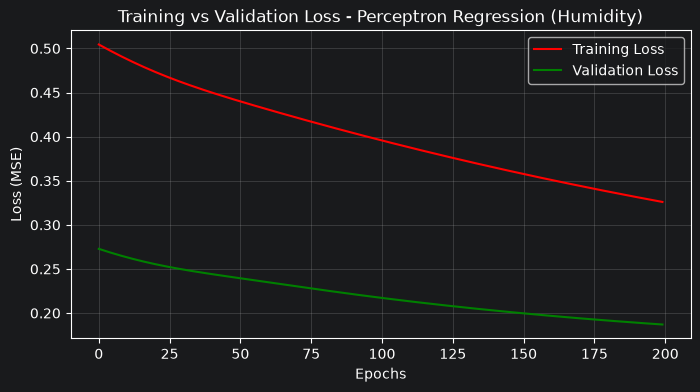

In [23]:
# Plot training and validation loss - same plot as Tutorial 10
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_hist_r,     'r', label='Training Loss')
plt.plot(val_loss_hist_r, 'g', label='Validation Loss')
plt.title('Training vs Validation Loss - Perceptron Regression (Humidity)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

perceptron_reg.eval()
with torch.no_grad():
    y_pred_norm = perceptron_reg(X_te_r_t).numpy()

# Reverse target scaling - same step as Tutorial 10
y_pred_actual = y_scaler_r.inverse_transform(y_pred_norm)
y_true_actual = y_scaler_r.inverse_transform(y_te_r)

mae  = mean_absolute_error(y_true_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
r2   = r2_score(y_true_actual, y_pred_actual)

print(f"Mean Absolute Error     : {mae:.4f}")
print(f"Root Mean Squared Error : {rmse:.4f}")
print(f"R2 Score                : {r2:.4f}")

Mean Absolute Error     : 2.0406
Root Mean Squared Error : 2.5847
R2 Score                : 0.8716


---
## Part 11: Perceptron for Classification 

In Tutorial 10 you built:
```python
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, activation='sigmoid', input_shape=(4,))
])
model.compile(optimizer=Adam(lr=0.001), loss='binary_crossentropy', metrics=['accuracy'])
```

Here is the equivalent in PyTorch. Inputs: `Rainfall`, `Soil_pH`, `Slope`, `Elevation` → Target: `Suitability` (0 or 1).

In [25]:
torch.manual_seed(42)

# Single sigmoid neuron - equivalent to Dense(1, activation='sigmoid')
# Inputs: Rainfall, Soil_pH, Slope, Elevation (4 features)
# Output: Suitability probability (0 = Not Suitable, 1 = Suitable)
perceptron_cls = nn.Sequential(
    nn.Linear(4, 1),   # 4 land inputs, 1 output
    nn.Sigmoid()       # same as activation='sigmoid' in Keras
)

criterion_cls = nn.BCELoss()                                       # binary_crossentropy
optimizer_cls = optim.Adam(perceptron_cls.parameters(), lr=0.001)  # Adam(lr=0.001)

print(perceptron_cls)

Sequential(
  (0): Linear(in_features=4, out_features=1, bias=True)
  (1): Sigmoid()
)


In [26]:
NUM_EPOCHS = 200
loss_hist_c, val_loss_hist_c = [], []
acc_hist_c,  val_acc_hist_c  = [], []

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    perceptron_cls.train()
    out  = perceptron_cls(X_tr_c_t)
    loss = criterion_cls(out, y_tr_c_t)
    optimizer_cls.zero_grad()
    loss.backward()
    optimizer_cls.step()

    with torch.no_grad():
        preds = (out > 0.5).float()
        acc   = (preds == y_tr_c_t).float().mean().item()
    loss_hist_c.append(loss.item())
    acc_hist_c.append(acc)

    # --- Validation ---
    perceptron_cls.eval()
    with torch.no_grad():
        val_out  = perceptron_cls(X_val_c_t)
        val_loss = criterion_cls(val_out, y_val_c_t)
        val_preds = (val_out > 0.5).float()
        val_acc   = (val_preds == y_val_c_t).float().mean().item()
    val_loss_hist_c.append(val_loss.item())
    val_acc_hist_c.append(val_acc)

    if epoch % 40 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc:.3f}")

Epoch   0 | Loss: 0.4989 | Val Loss: 0.5068 | Val Acc: 1.000
Epoch  40 | Loss: 0.4426 | Val Loss: 0.4499 | Val Acc: 1.000
Epoch  80 | Loss: 0.3943 | Val Loss: 0.4008 | Val Acc: 1.000
Epoch 120 | Loss: 0.3532 | Val Loss: 0.3588 | Val Acc: 1.000
Epoch 160 | Loss: 0.3182 | Val Loss: 0.3227 | Val Acc: 1.000


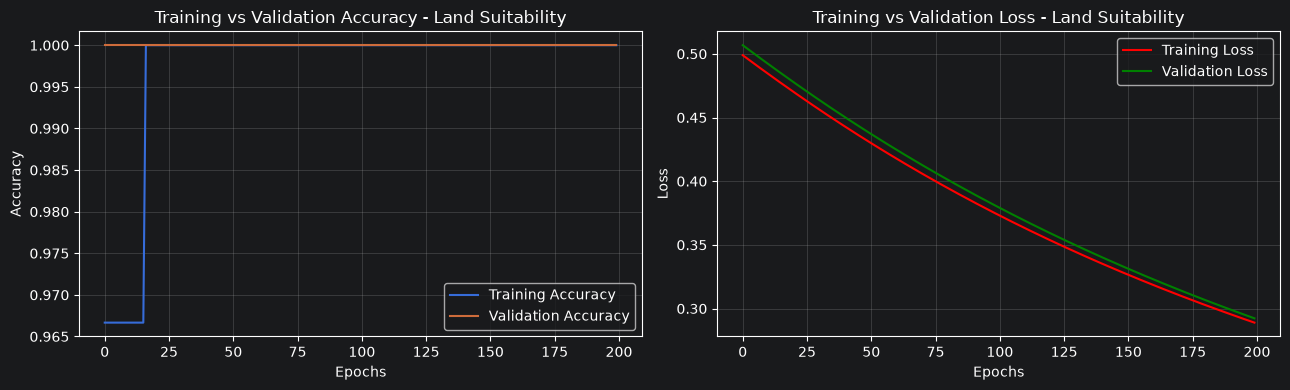

In [27]:
# Plot accuracy and loss - same plots as Tutorial 10
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(acc_hist_c,     label='Training Accuracy')
axes[0].plot(val_acc_hist_c, label='Validation Accuracy')
axes[0].set_title('Training vs Validation Accuracy - Land Suitability')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(loss_hist_c,     'r', label='Training Loss')
axes[1].plot(val_loss_hist_c, 'g', label='Validation Loss')
axes[1].set_title('Training vs Validation Loss - Land Suitability')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import accuracy_score, classification_report

perceptron_cls.eval()
with torch.no_grad():
    y_pred_prob = perceptron_cls(X_te_c_t)
    y_pred_bin  = (y_pred_prob >= 0.5).int().numpy().flatten()

print("Test Accuracy:", accuracy_score(y_te_c, y_pred_bin))
print("\nClassification Report:")
print(classification_report(y_te_c, y_pred_bin, target_names=['Not Suitable', 'Suitable']))

Test Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

Not Suitable       1.00      1.00      1.00         5
    Suitable       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



---
## Part 12: Perceptron with Non-linear Activation

In Tutorial 10 you tried different activation functions on the same Weather regression task and filled in this table:

| Activation Function | MAE | RMSE | R2 Score |
|---------------------|-----|------|----------|
| relu | | | |
| tanh | | | |
| softmax | | | |

Reproduce the same experiment in PyTorch below.

In [29]:
# Try different activations on the Weather regression task (same as Tutorial 10)
activations = {
    'relu'    : nn.ReLU(),
    'tanh'    : nn.Tanh(),
    'sigmoid' : nn.Sigmoid(),
    'linear'  : None   # no activation layer needed
}

print(f"{'Activation':>10}  {'MAE':>8}  {'RMSE':>8}  {'R2':>8}")
print("-" * 42)

for act_name, act_layer in activations.items():
    torch.manual_seed(42)

    if act_layer is None:
        m = nn.Sequential(nn.Linear(3, 1))
    else:
        m = nn.Sequential(nn.Linear(3, 1), act_layer)

    opt = optim.Adam(m.parameters(), lr=0.001)
    crit = nn.MSELoss()

    for _ in range(200):
        m.train()
        out  = m(X_tr_r_t)
        loss = crit(out, y_tr_r_t)
        opt.zero_grad()
        loss.backward()
        opt.step()

    m.eval()
    with torch.no_grad():
        yp = y_scaler_r.inverse_transform(m(X_te_r_t).numpy())
    yt = y_scaler_r.inverse_transform(y_te_r)

    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    print(f"{act_name:>10}  {mae:>8.4f}  {rmse:>8.4f}  {r2:>8.4f}")

Activation       MAE      RMSE        R2
------------------------------------------
      relu    3.3344    3.8321    0.7178
      tanh    2.4958    3.2581    0.7960
   sigmoid    4.8980    5.5654    0.4048
    linear    2.0406    2.5847    0.8716


---
## Part 13: Shallow MLP — Classification 

In Tutorial 11 you added hidden layers to the perceptron. You built:
```python
model_c = Sequential([
    Input(shape=(4,)),
    Dense(units=1, activation='relu'),   # hidden layer
    Dense(units=1, activation='sigmoid') # output layer
])
```

Here is the same progression in PyTorch — one hidden layer for land suitability classification.

In [30]:
# Equivalent to Tutorial 11's shallow network:
# Input(shape=(4,)) -> Dense(n, relu) -> Dense(1, sigmoid)

class ShallowClassifier(nn.Module):
    """
    One hidden layer classifier for land suitability.
    Equivalent to Tutorial 11 shallow MLP with one hidden layer.
    Inputs: Rainfall, Soil_pH, Slope, Elevation (4 features)
    Output: Suitability probability
    """
    def __init__(self, hidden_size=8):
        super().__init__()
        self.fc1 = nn.Linear(4, hidden_size)   # hidden layer (same as Dense(hidden_size, relu))
        self.fc2 = nn.Linear(hidden_size, 1)   # output layer (same as Dense(1, sigmoid))

    def forward(self, x):
        x = torch.relu(self.fc1(x))            # relu - same as activation='relu'
        x = torch.sigmoid(self.fc2(x))         # sigmoid - same as activation='sigmoid'
        return x

model_shallow_c = ShallowClassifier(hidden_size=8)
print(model_shallow_c)
print("Parameters:", sum(p.numel() for p in model_shallow_c.parameters()))

ShallowClassifier(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)
Parameters: 49


In [31]:
def train_classifier(model, X_tr, y_tr, X_val, y_val, lr=0.001, epochs=400):
    """
    Reusable training function — equivalent to model.fit() in Keras.
    Returns a history dict with keys: loss, val_loss, accuracy, val_accuracy.
    """
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_h, val_loss_h, acc_h, val_acc_h = [], [], [], []

    for epoch in range(epochs):
        # --- Training step ---
        model.train()                            # enables Dropout, BatchNorm etc.
        out  = model(X_tr)
        loss = criterion(out, y_tr)
        optimizer.zero_grad()                    # clear gradients from last step
        loss.backward()                          # compute new gradients
        optimizer.step()                         # update weights

        with torch.no_grad():
            acc = ((out > 0.5).float() == y_tr).float().mean().item()
        loss_h.append(loss.item())
        acc_h.append(acc)

        # --- Validation step ---
        model.eval()                             # disables Dropout, BatchNorm etc.
        with torch.no_grad():
            v_out  = model(X_val)
            v_loss = criterion(v_out, y_val)
            v_acc  = ((v_out > 0.5).float() == y_val).float().mean().item()
        val_loss_h.append(v_loss.item())
        val_acc_h.append(v_acc)

    return {"loss": loss_h, "val_loss": val_loss_h,
            "accuracy": acc_h, "val_accuracy": val_acc_h}


torch.manual_seed(42)
history_shallow_c = train_classifier(
    model_shallow_c, X_tr_c_t, y_tr_c_t, X_val_c_t, y_val_c_t, epochs=400
)

model_shallow_c.eval()
with torch.no_grad():
    y_pred = (model_shallow_c(X_te_c_t) >= 0.5).int().numpy().flatten()

print("Shallow MLP Test Accuracy:", accuracy_score(y_te_c, y_pred))
print(classification_report(y_te_c, y_pred, target_names=['Not Suitable', 'Suitable']))


Shallow MLP Test Accuracy: 1.0
              precision    recall  f1-score   support

Not Suitable       1.00      1.00      1.00         5
    Suitable       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



###  Exercise 4 — Vary neurons 

In Tutorial 11 you filled in this table by changing the number of neurons in the hidden layer:

| Neurons in hidden layer | Accuracy |
|-------------------------|----------|
| 1 | |
| 2 | |
| 3 | |
| 4 | |
| 5 | |

Reproduce the same experiment in PyTorch using the loop below. Compare your results with Tutorial 11.

In [32]:
# ---- Exercise 4 Solution ----
print(f"{'Neurons':>8}  {'Test Accuracy':>15}")
print("-" * 28)

for n in range(1, 7):
    torch.manual_seed(42)
    m = ShallowClassifier(hidden_size=n)
    train_classifier(m, X_tr_c_t, y_tr_c_t, X_val_c_t, y_val_c_t, epochs=500)

    m.eval()
    with torch.no_grad():
        preds = (m(X_te_c_t) >= 0.5).int().numpy().flatten()
    acc = accuracy_score(y_te_c, preds)
    print(f"{n:>8}  {acc:>15.3f}")

 Neurons    Test Accuracy
----------------------------
       1            1.000
       2            1.000
       3            1.000
       4            1.000
       5            1.000
       6            1.000


---
## Part 14: Shallow MLP — Regression 

In Tutorial 11 you used `Weather_Data.csv` to build shallow regression networks. Here is the same model in PyTorch.

Keras equivalent:
```python
model_r = Sequential([
    Input(shape=(3,)),
    Dense(units=1, activation='relu'),   # hidden layer
    Dense(units=1, activation='linear')  # output layer
])
```

In [33]:
def train_regressor(model, X_tr, y_tr, X_val, y_val, lr=0.001, epochs=500,
                    optimizer_class=optim.Adam):
    """
    Reusable regression training function - equivalent to model.fit() in Keras.
    Returns a history dict with keys: loss, val_loss.
    """
    criterion = nn.MSELoss()
    optimizer = optimizer_class(model.parameters(), lr=lr)

    loss_h, val_loss_h = [], []

    for epoch in range(epochs):
        model.train()
        out  = model(X_tr)
        loss = criterion(out, y_tr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_h.append(loss.item())

        model.eval()
        with torch.no_grad():
            v_loss = criterion(model(X_val), y_val)
        val_loss_h.append(v_loss.item())

    return {"loss": loss_h, "val_loss": val_loss_h}


class ShallowRegressor(nn.Module):
    """
    One hidden layer regressor for humidity prediction.
    Inputs: AirTemp_C, Rain_mm, WindSpeed_mps (3 features)
    Output: Humidity_pct (1 value)
    """
    def __init__(self, hidden_size=5):
        super().__init__()
        self.fc1 = nn.Linear(3, hidden_size)  # 3 weather inputs -> hidden neurons
        self.fc2 = nn.Linear(hidden_size, 1)  # 1 output (humidity)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # relu hidden activation
        return self.fc2(x)           # linear output - same as activation='linear' in Keras


torch.manual_seed(42)
model_shallow_r = ShallowRegressor(hidden_size=5)
history_r = train_regressor(
    model_shallow_r, X_tr_r_t, y_tr_r_t, X_val_r_t, y_val_r_t, epochs=500
)

# Evaluate with R2, MAE, RMSE - same as Tutorial 10/11
model_shallow_r.eval()
with torch.no_grad():
    y_pred_norm = model_shallow_r(X_te_r_t).numpy()

y_pred_actual = y_scaler_r.inverse_transform(y_pred_norm)
y_true_actual = y_scaler_r.inverse_transform(y_te_r)

print(f"MAE  : {mean_absolute_error(y_true_actual, y_pred_actual):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_true_actual, y_pred_actual)):.4f}")
print(f"R2   : {r2_score(y_true_actual, y_pred_actual):.4f}")


MAE  : 2.2076
RMSE : 2.5391
R2   : 0.8761


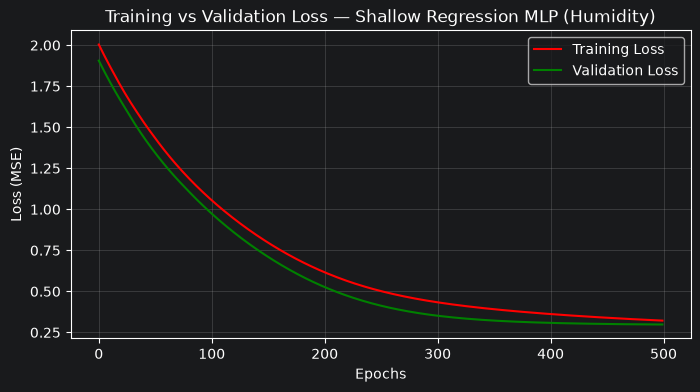

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(history_r['loss'],     'r', label='Training Loss')
plt.plot(history_r['val_loss'], 'g', label='Validation Loss')
plt.title('Training vs Validation Loss — Shallow Regression MLP (Humidity)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

###  Exercise 5 — Vary neurons, regression 

In Tutorial 11 you filled in the regression table for 1–5 neurons. Reproduce it in PyTorch and compare your results.

| Neurons in hidden layer | MAE | RMSE | R2 Score |
|-------------------------|-----|------|----------|
| 1 | | | |
| 2 | | | |
| 3 | | | |
| 4 | | | |
| 5 | | | |

In [35]:
# ---- Exercise 5 Solution ----
print(f"{'Neurons':>8}  {'MAE':>8}  {'RMSE':>8}  {'R2':>8}")
print("-" * 40)

for n in range(1, 6):
    torch.manual_seed(42)
    m = ShallowRegressor(hidden_size=n)
    train_regressor(m, X_tr_r_t, y_tr_r_t, X_val_r_t, y_val_r_t, epochs=500)

    m.eval()
    with torch.no_grad():
        yp = y_scaler_r.inverse_transform(m(X_te_r_t).numpy())
    yt = y_scaler_r.inverse_transform(y_te_r)

    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    print(f"{n:>8}  {mae:>8.4f}  {rmse:>8.4f}  {r2:>8.4f}")

 Neurons       MAE      RMSE        R2
----------------------------------------
       1    6.6462    7.4845   -0.0764
       2    1.8078    1.9331    0.9282
       3    1.8564    2.1388    0.9121
       4    1.7587    1.9334    0.9282
       5    2.2076    2.5391    0.8761


---
## Part 15: Deep MLP — Multiple Hidden Layers 

In Tutorial 11 you compared 1, 2, and 3 hidden layers on the land suitability dataset:

| Number of hidden layers | Precision | Recall | F1-score |
|-------------------------|-----------|--------|----------|
| 1 | | | |
| 2 | | | |
| 3 | | | |

Here is the same comparison in PyTorch.

In [36]:
class MLPClassifier(nn.Module):
    """
    Configurable MLP for land suitability classification.
    Mirrors the architecture experiments in Tutorial 11.
    Inputs: Rainfall, Soil_pH, Slope, Elevation (4 features)
    """
    def __init__(self, num_layers=1, hidden_size=8):
        super().__init__()

        layers = [nn.Linear(4, hidden_size), nn.ReLU()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.ReLU()]
        layers += [nn.Linear(hidden_size, 1), nn.Sigmoid()]

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Compare 1, 2, 3 hidden layers - same table as Tutorial 11
from sklearn.metrics import precision_recall_fscore_support

print(f"{'Layers':>8}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}  {'Accuracy':>10}")
print("-" * 52)

for n_layers in [1, 2, 3]:
    torch.manual_seed(42)
    m = MLPClassifier(num_layers=n_layers, hidden_size=8)
    train_classifier(m, X_tr_c_t, y_tr_c_t, X_val_c_t, y_val_c_t, epochs=400)

    m.eval()
    with torch.no_grad():
        preds = (m(X_te_c_t) >= 0.5).int().numpy().flatten()

    p, r, f, _ = precision_recall_fscore_support(y_te_c, preds, average='weighted')
    acc = accuracy_score(y_te_c, preds)
    print(f"{n_layers:>8}  {p:>10.3f}  {r:>8.3f}  {f:>8.3f}  {acc:>10.3f}")

  Layers   Precision    Recall        F1    Accuracy
----------------------------------------------------
       1       1.000     1.000     1.000       1.000
       2       1.000     1.000     1.000       1.000
       3       1.000     1.000     1.000       1.000


---
## Part 16: The Sweet Spot  

In Tutorial 11 you learned about the **sweet spot** — the epoch where validation loss is minimum. In PyTorch you identify it the same way: by plotting the training and validation loss curves.

> Before sweet spot → still learning  
> At sweet spot → best balance between learning and generalisation  
> After sweet spot → model starts memorising the training data (overfitting)

Sweet spot at epoch: 995
Best val loss      : 0.0000


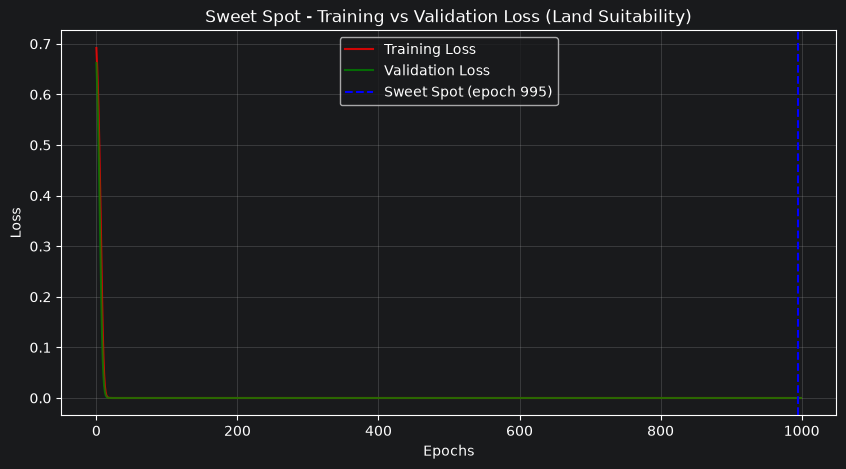

In [37]:
# Train a deeper network for many epochs to deliberately show the sweet spot
# Same concept as Tutorial 11 - using land_suitability dataset
torch.manual_seed(42)

overfit_model = MLPClassifier(num_layers=3, hidden_size=32)
history_overfit = train_classifier(
    overfit_model, X_tr_c_t, y_tr_c_t, X_val_c_t, y_val_c_t,
    epochs=1000, lr=0.01
)

# Find the sweet spot - epoch with lowest validation loss
best_epoch = history_overfit['val_loss'].index(min(history_overfit['val_loss']))
print(f"Sweet spot at epoch: {best_epoch}")
print(f"Best val loss      : {min(history_overfit['val_loss']):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(history_overfit['loss'],     'r', label='Training Loss', alpha=0.8)
plt.plot(history_overfit['val_loss'], 'g', label='Validation Loss', alpha=0.8)
plt.axvline(x=best_epoch, color='blue', linestyle='--',
            label=f'Sweet Spot (epoch {best_epoch})')
plt.title('Sweet Spot - Training vs Validation Loss (Land Suitability)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## Part 17: Early Stopping 

In Tutorial 11 you used:
```python
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           min_delta=0.0001, restore_best_weights=True)
model.fit(..., callbacks=[early_stop])
```

PyTorch has no built-in callback system — you implement Early Stopping directly inside the training loop. The logic is identical: track the best validation loss and stop when it stops improving.

**Key Parameters (same as Tutorial 11):**

| Parameter | Meaning |
|-----------|---------|
| `monitor='val_loss'` | Watch validation loss |
| `patience=5` | Stop after 5 epochs with no improvement |
| `min_delta=0.0001` | Minimum improvement to count |
| `restore_best_weights=True` | Restore weights from the best epoch |

In [38]:
class EarlyStopping:
    """
    PyTorch implementation of Keras EarlyStopping callback (Tutorial 11).
    Same parameters: patience, min_delta, restore_best_weights.
    """
    def __init__(self, patience=5, min_delta=0.0001, restore_best_weights=True):
        self.patience             = patience
        self.min_delta            = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss            = float('inf')
        self.best_weights         = None
        self.counter              = 0

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            if self.restore_best_weights:
                import copy
                self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.restore_best_weights and self.best_weights:
                model.load_state_dict(self.best_weights)  # restore best weights
            return True   # stop training
        return False

Early stopping at epoch 128  (best val loss: 0.2953)


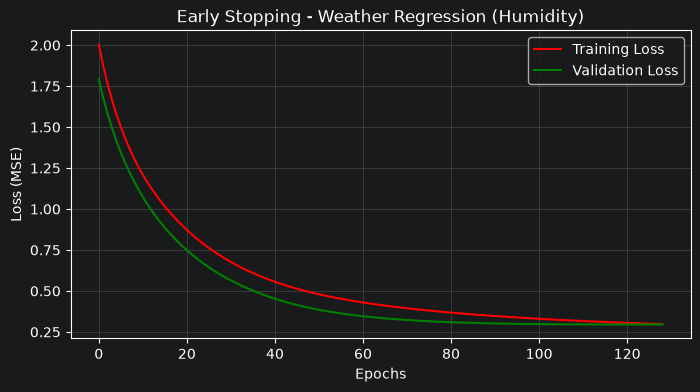

MAE: 2.1851  RMSE: 2.4782  R2: 0.8820


In [39]:
# Training loop with Early Stopping - Weather regression (same as Tutorial 11)
torch.manual_seed(42)

model_es    = ShallowRegressor(hidden_size=5)
criterion_es = nn.MSELoss()
optimizer_es = optim.SGD(model_es.parameters(), lr=0.01)  # SGD - same as Tutorial 11

early_stop = EarlyStopping(patience=10, min_delta=0.0001, restore_best_weights=True)

loss_h_es, val_loss_h_es = [], []

for epoch in range(1000):   # large max - Early Stopping will cut it short
    model_es.train()
    out  = model_es(X_tr_r_t)
    loss = criterion_es(out, y_tr_r_t)
    optimizer_es.zero_grad()
    loss.backward()
    optimizer_es.step()
    loss_h_es.append(loss.item())

    model_es.eval()
    with torch.no_grad():
        val_loss = criterion_es(model_es(X_val_r_t), y_val_r_t)
    val_loss_h_es.append(val_loss.item())

    if early_stop(val_loss.item(), model_es):
        print(f"Early stopping at epoch {epoch}  (best val loss: {early_stop.best_loss:.4f})")
        break

plt.figure(figsize=(8, 4))
plt.plot(loss_h_es,     'r', label='Training Loss')
plt.plot(val_loss_h_es, 'g', label='Validation Loss')
plt.title('Early Stopping - Weather Regression (Humidity)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

model_es.eval()
with torch.no_grad():
    yp = y_scaler_r.inverse_transform(model_es(X_te_r_t).numpy())
yt = y_scaler_r.inverse_transform(y_te_r)
print(f"MAE: {mean_absolute_error(yt, yp):.4f}  RMSE: {np.sqrt(mean_squared_error(yt, yp)):.4f}  R2: {r2_score(yt, yp):.4f}")

---
## Part 18: Dropout Regularisation 

In Tutorial 11 you added Dropout layers to the land suitability model:
```python
model_d = Sequential([
    Dense(128, activation='relu', input_shape=(4,)),
    Dropout(0.3),   # drops 30% neurons
    Dense(64,  activation='relu'),
    Dropout(0.2),   # drops 20%
    Dense(1, activation='sigmoid')
])
```

In PyTorch `nn.Dropout(p)` works identically — it is only active during `model.train()` and is automatically switched off during `model.eval()`.

> **Key difference from TF:** In PyTorch you must explicitly call `model.train()` before training steps (enables dropout) and `model.eval()` before inference (disables dropout). Keras handles this automatically inside `model.fit()` and `model.predict()`.

In [40]:
class MLPWithDropout(nn.Module):
    """
    MLP for land suitability with Dropout regularisation.
    Equivalent to Tutorial 11's Dropout example.
    Inputs: Rainfall, Soil_pH, Slope, Elevation (4 features)
    """
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),      # deactivates dropout_rate% of neurons in training
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# Compare no dropout vs 0.2 vs 0.5 - same experiment as Tutorial 11
print(f"{'Dropout rate':>14}  {'Test Accuracy':>14}")
print("-" * 32)

for rate in [0.0, 0.2, 0.5]:
    torch.manual_seed(42)
    m = MLPWithDropout(dropout_rate=rate)
    train_classifier(m, X_tr_c_t, y_tr_c_t, X_val_c_t, y_val_c_t, epochs=400)

    m.eval()
    with torch.no_grad():
        preds = (m(X_te_c_t) >= 0.5).int().numpy().flatten()
    acc = accuracy_score(y_te_c, preds)
    print(f"{rate:>14.1f}  {acc:>14.3f}")

  Dropout rate   Test Accuracy
--------------------------------
           0.0           1.000
           0.2           1.000
           0.5           1.000


---
## Part 19: Saving and Loading Models

In Keras you used `model.save('model.h5')` or `model.save_weights()`. PyTorch uses `state_dict()` — a dictionary of all parameter tensors.

In [41]:
# Save - equivalent to model.save_weights()
torch.save(model_shallow_c.state_dict(), "land_suitability_mlp.pth")
print("Model saved")

for k, v in torch.load("land_suitability_mlp.pth").items():
    print(f"  {k:20s}  {v.shape}")

Model saved
  fc1.weight            torch.Size([8, 4])
  fc1.bias              torch.Size([8])
  fc2.weight            torch.Size([1, 8])
  fc2.bias              torch.Size([1])


In [42]:
# Load - must recreate the same architecture first
loaded = ShallowClassifier(hidden_size=8)
loaded.load_state_dict(torch.load("land_suitability_mlp.pth"))
loaded.eval()
print("Model loaded")

# Verify predictions are identical
with torch.no_grad():
    orig_out   = model_shallow_c(X_te_c_t)
    loaded_out = loaded(X_te_c_t)
print("Predictions match:", torch.allclose(orig_out, loaded_out))

Model loaded
Predictions match: True


In [43]:
# Checkpoint - saves everything needed to resume training (no Keras equivalent)
checkpoint = {
    'epoch'               : NUM_EPOCHS,
    'model_state_dict'    : model_shallow_c.state_dict(),
    'optimizer_state_dict': optimizer_cls.state_dict(),
    'val_loss'            : val_loss_hist_c[-1]
}
torch.save(checkpoint, "checkpoint.pth")
print("Checkpoint saved")

# To resume training:
# ckpt = torch.load('checkpoint.pth')
# model.load_state_dict(ckpt['model_state_dict'])
# optimizer.load_state_dict(ckpt['optimizer_state_dict'])
# start_epoch = ckpt['epoch']

Checkpoint saved


---
## Mini Project — Hyperparameter Comparison 

In Tutorial 11 you used Grid Search / Random Search via SciKeras to tune hyperparameters. PyTorch models do not natively support the sklearn API, but you can run a manual grid search as below (equivalent to what SciKeras automated).

Use the reusable training functions from Parts 13–14 to complete the experiment table:

| Hidden size | Layers | Optimiser | LR | Epochs | Dropout | Test Acc (land) | R² (weather) |
|-------------|--------|-----------|-----|--------|---------|-----------------|---------------|
| 8 | 1 | Adam | 0.001 | 400 | 0.0 | ? | ? |
| 16 | 1 | Adam | 0.001 | 400 | 0.0 | ? | ? |
| 8 | 2 | Adam | 0.001 | 400 | 0.0 | ? | ? |
| 8 | 1 | SGD | 0.01 | 400 | 0.0 | ? | ? |
| 16 | 2 | Adam | 0.001 | 400 | 0.2 | ? | ? |

In [44]:
configs = [
    dict(hidden=8,  layers=1, opt=optim.Adam, lr=0.001, dropout=0.0),
    dict(hidden=16, layers=1, opt=optim.Adam, lr=0.001, dropout=0.0),
    dict(hidden=8,  layers=2, opt=optim.Adam, lr=0.001, dropout=0.0),
    dict(hidden=8,  layers=1, opt=optim.SGD,  lr=0.01,  dropout=0.0),
    dict(hidden=16, layers=2, opt=optim.Adam, lr=0.001, dropout=0.2),
]

print(f"{'H':>4} {'L':>3} {'Opt':>6} {'LR':>6} {'DR':>5} | {'Acc':>6} {'R2':>8}")
print("-" * 50)

for cfg in configs:
    torch.manual_seed(42)

    # Classification - land suitability
    if cfg['dropout'] > 0:
        mc = MLPWithDropout(dropout_rate=cfg['dropout'])
    else:
        mc = MLPClassifier(num_layers=cfg['layers'], hidden_size=cfg['hidden'])
    train_classifier(mc, X_tr_c_t, y_tr_c_t, X_val_c_t, y_val_c_t,
                     lr=cfg['lr'], epochs=400)
    mc.eval()
    with torch.no_grad():
        preds_c = (mc(X_te_c_t) >= 0.5).int().numpy().flatten()
    acc = accuracy_score(y_te_c, preds_c)

    # Regression - weather
    torch.manual_seed(42)
    mr = ShallowRegressor(hidden_size=cfg['hidden'])
    train_regressor(mr, X_tr_r_t, y_tr_r_t, X_val_r_t, y_val_r_t,
                    lr=cfg['lr'], epochs=400, optimizer_class=cfg['opt'])
    mr.eval()
    with torch.no_grad():
        yp = y_scaler_r.inverse_transform(mr(X_te_r_t).numpy())
    yt = y_scaler_r.inverse_transform(y_te_r)
    r2 = r2_score(yt, yp)

    opt_name = cfg['opt'].__name__
    print(f"{cfg['hidden']:>4} {cfg['layers']:>3} {opt_name:>6} {cfg['lr']:>6} "
          f"{cfg['dropout']:>5} | {acc:>6.3f} {r2:>8.4f}")

   H   L    Opt     LR    DR |    Acc       R2
--------------------------------------------------
   8   1   Adam  0.001   0.0 |  1.000   0.9381
  16   1   Adam  0.001   0.0 |  1.000   0.9546
   8   2   Adam  0.001   0.0 |  1.000   0.9381
   8   1    SGD   0.01   0.0 |  1.000   0.9526
  16   2   Adam  0.001   0.2 |  1.000   0.9546
